# Brain Tumor Classification using MobileNetV2
End-to-end pipeline: EDA → Preprocessing → Training → Fine-tuning → Evaluation → TFLite Conversion

**Dataset:** T1-weighted MRI Images (Grayscale)
**Classes:** glioma, meningioma, no_tumor, pituitary

## 1. Setup & Imports

In [1]:
import os
import shutil
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

tf.random.set_seed(42)
np.random.seed(42)

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
print(f'TensorFlow Version: {tf.__version__}')
print(f'GPUs : {len(gpus)}  ->  {[g.name for g in gpus]}')

TensorFlow Version: 2.20.0
GPUs : 1  ->  ['/physical_device:GPU:0']


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Data Configuration

In [4]:
DRIVE_DATASET_DIR = '/content/drive/MyDrive/Brain_Tumor_Classification/TumorDataset'
LOCAL_DATASET_DIR = '/content/TumorDataset'

if not os.path.exists(LOCAL_DATASET_DIR) and os.path.exists(DRIVE_DATASET_DIR):
    print('Copying dataset from Google Drive to local Colab storage...')
    shutil.copytree(DRIVE_DATASET_DIR, LOCAL_DATASET_DIR)

BASE_DIR = LOCAL_DATASET_DIR if os.path.exists(LOCAL_DATASET_DIR) else DRIVE_DATASET_DIR
TRAIN_DIR = os.path.join(BASE_DIR, 'Training')
TEST_DIR = os.path.join(BASE_DIR, 'Testing')
print(f'Using dataset from: {BASE_DIR}')

CLASSES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
NUM_CLASSES = len(CLASSES)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

## 3. Exploratory Data Analysis (EDA)

In [5]:
# Initialize dictionary to store counts
import pandas as pd
class_counts = {'Training': {}, 'Testing': {}}

# Iterate and count
for split_name in ['Training', 'Testing']:
    split_path = os.path.join(BASE_DIR, split_name)
    for category in CLASSES:
        category_path = os.path.join(split_path, category)
        if os.path.exists(category_path):
            count = len(os.listdir(category_path))
            class_counts[split_name][category] = count
        else:
            class_counts[split_name][category] = 0

# Print the collected class distribution counts
print("\nClass Distribution:")
for split, categories_data in class_counts.items():
    print(f"\n{split} Set:")
    for category, count in categories_data.items():
        print(f"  {category}: {count} images")


Class Distribution:

Training Set:
  glioma: 1400 images
  meningioma: 1400 images
  no_tumor: 1400 images
  pituitary: 1400 images

Testing Set:
  glioma: 400 images
  meningioma: 400 images
  no_tumor: 400 images
  pituitary: 400 images


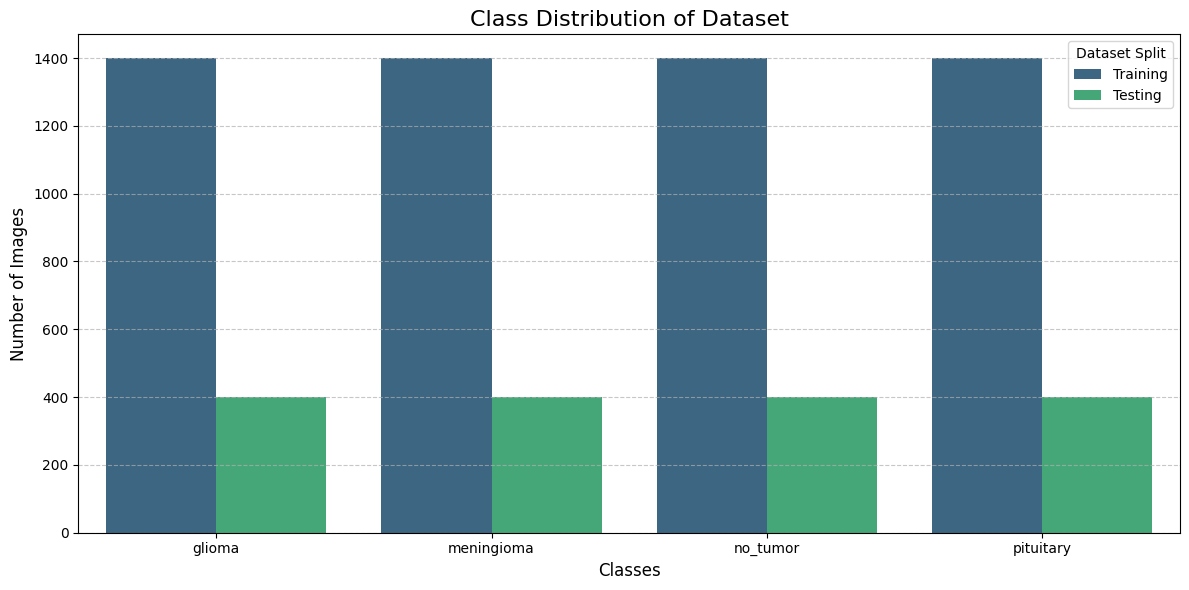

In [6]:
# Convert to DataFrame for easier plotting
df_counts = pd.DataFrame(class_counts).T.stack().reset_index()
df_counts.columns = ['Split', 'Classes', 'Count']

# Create a bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x='Classes', y='Count', hue='Split', data=df_counts, palette='viridis')

# Add title, labels, and legend
plt.title('Class Distribution of Dataset', fontsize=16)
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.legend(title='Dataset Split')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()

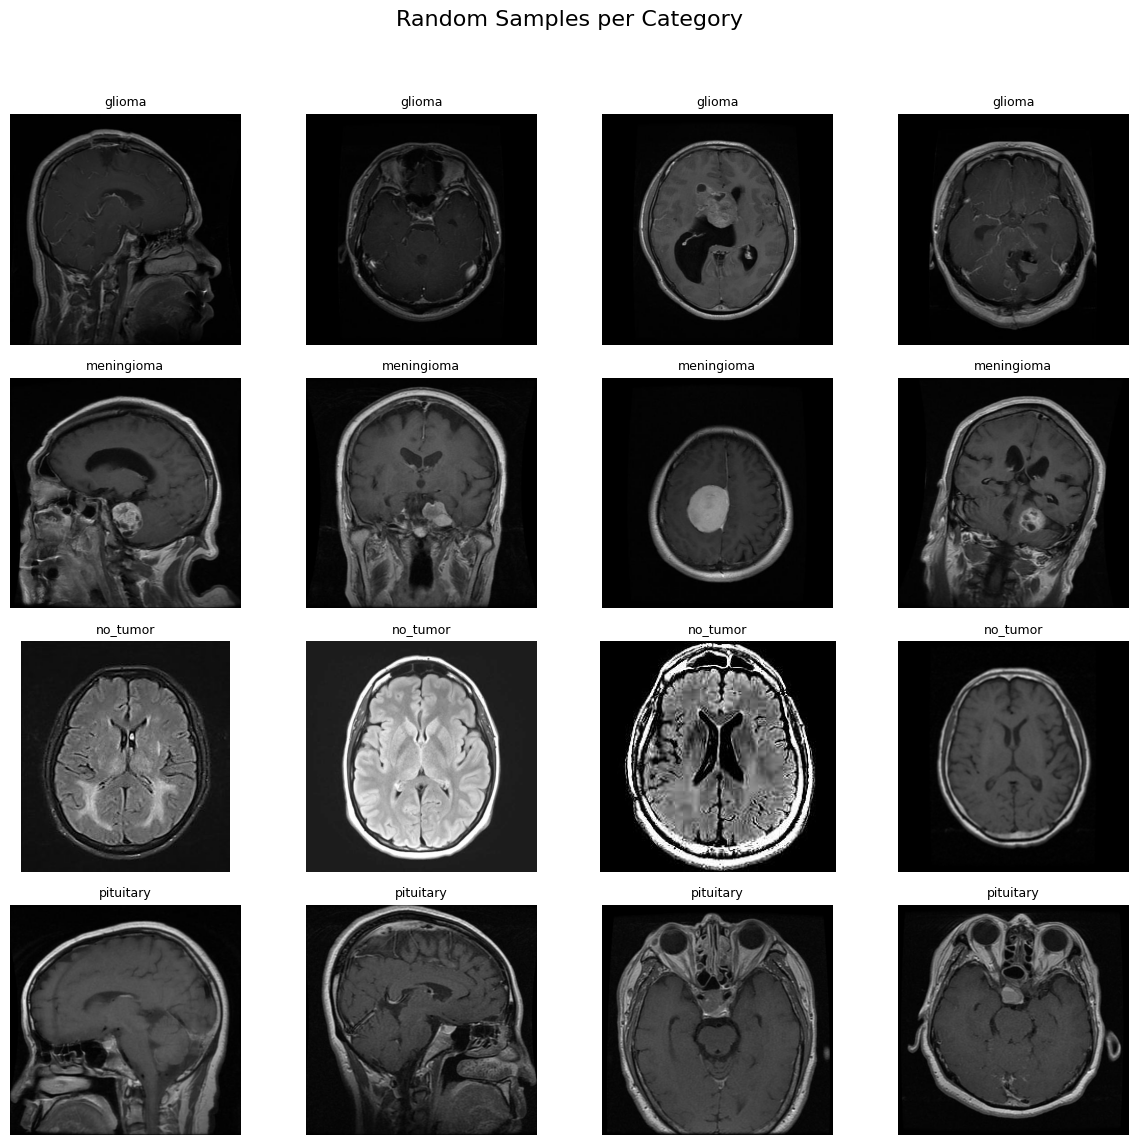

In [7]:
import random

sample_images = []
num_samples_per_category = 4

print("Collecting 4 random sample images per category...")
for category in CLASSES:
    category_path = os.path.join(BASE_DIR, 'Training', category)
    if os.path.exists(category_path):
        image_filenames = [f for f in os.listdir(category_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if image_filenames:
            # Randomly select samples
            selected_samples = random.sample(image_filenames, min(num_samples_per_category, len(image_filenames)))
            for img_name in selected_samples:
                img_path = os.path.join(category_path, img_name)
                img = cv2.imread(img_path)
                if img is not None:
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    sample_images.append({'image': img_rgb, 'category': category})
        else:
            print(f"No images found in {category_path}")

# Create a grid layout
num_categories = len(CLASSES)
fig, axes = plt.subplots(num_categories, num_samples_per_category, figsize=(num_samples_per_category * 3, num_categories * 3))

for i, sample in enumerate(sample_images):
    row = i // num_samples_per_category
    col = i % num_samples_per_category
    ax = axes[row, col]
    ax.imshow(sample['image'])
    ax.set_title(sample['category'], fontsize=9)
    ax.axis('off')

plt.suptitle('Random Samples per Category', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

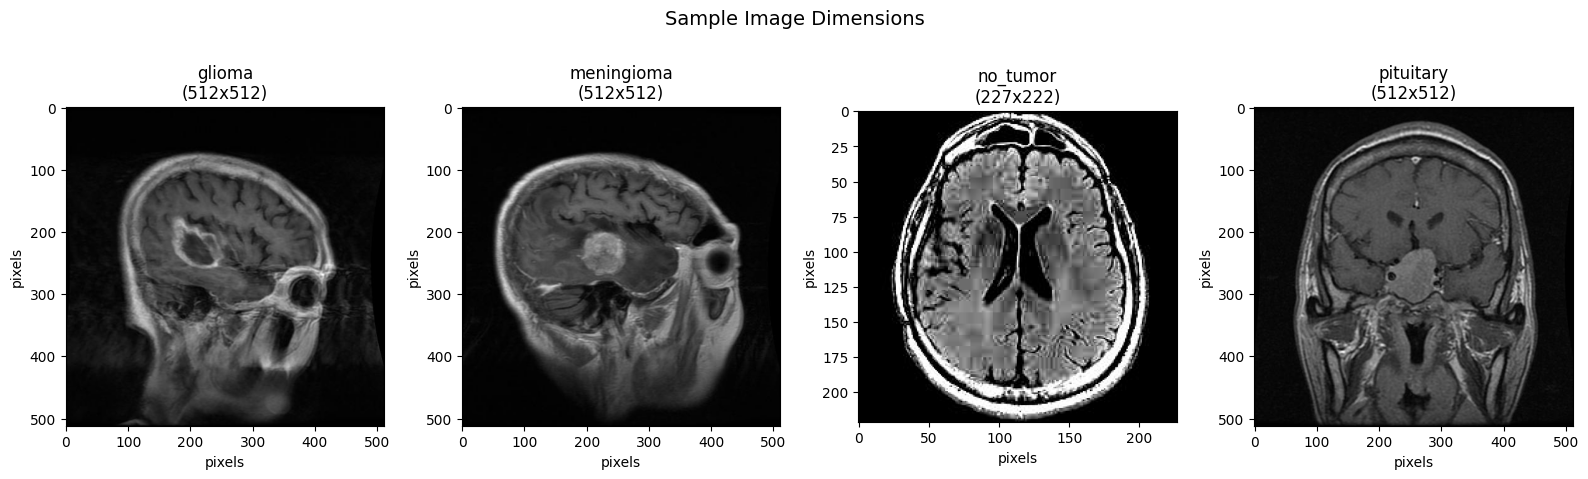

In [8]:
sample_images_info = []

for category in CLASSES:
    category_path = os.path.join(BASE_DIR, 'Training', category)
    if os.path.exists(category_path):
        image_filenames = [f for f in os.listdir(category_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if image_filenames:
            img_path = os.path.join(category_path, image_filenames[0])
            img = cv2.imread(img_path)
            if img is not None:
                height, width, _ = img.shape
                sample_images_info.append({
                    'image': cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
                    'category': category,
                    'dimensions': f'{width}x{height}'
                })

if sample_images_info:
    fig, axes = plt.subplots(1, len(sample_images_info), figsize=(16, 5))
    for i, sample in enumerate(sample_images_info):
        ax = axes[i] if len(sample_images_info) > 1 else axes
        ax.imshow(sample['image'])
        ax.set_title(f"{sample['category']}\n({sample['dimensions']})")
        ax.set_xlabel('pixels')
        ax.set_ylabel('pixels')
    plt.suptitle('Sample Image Dimensions', fontsize=14)
    plt.tight_layout()
    plt.show()

## 4. Data Generators with Augmentation

**Note:** Grayscale images are converted to 3-channel RGB by repeating the grayscale channel.

In [9]:
def grayscale_to_rgb(img):
    if len(img.shape) == 2:
        img = tf.expand_dims(img, axis=-1)
    img = tf.image.grayscale_to_rgb(img)
    return img


def preprocess_image(image, label):
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label


train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest',
    validation_split=0.15
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.15
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42,
    color_mode='rgb'
)

val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42,
    color_mode='rgb'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42,
    color_mode='rgb'
)

print(f"\nClass indices: {train_generator.class_indices}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")

Found 4760 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Class indices: {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}
Training samples: 4760
Validation samples: 840
Test samples: 1600


In [10]:
sample_batch = next(train_generator)
print(f"Batch shape: {sample_batch[0].shape}")
print(f"Batch labels shape: {sample_batch[1].shape}")

Batch shape: (32, 224, 224, 3)
Batch labels shape: (32, 4)


## 5. Build MobileNetV2 Model

In [11]:
def build_model(num_classes):
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

model = build_model(NUM_CLASSES)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,332 (9.99 MB)

 Trainable params: 361,348 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Phase 1 - Train Classification Head

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint('phase1_head_only.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
]

print("=" * 50)
print("PHASE 1: Training Classification Head")
print("=" * 50)

history_phase1 = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

PHASE 1: Training Classification Head
Epoch 1/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.5894 - loss: 1.0188 
Epoch 1: val_accuracy improved from None to 0.80000, saving model to phase1_head_only.keras

Epoch 1: finished saving model to phase1_head_only.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 2309s 15s/step - accuracy: 0.6975 - loss: 0.7649 - val_accuracy: 0.8000 - val_loss: 0.4681 - learning_rate: 0.0010
Epoch 2/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.7967 - loss: 0.5255
Epoch 2: val_accuracy improved from 0.80000 to 0.86548, saving model to phase1_head_only.keras

Epoch 2: finished saving model to phase1_head_only.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 88s 587ms/step - accuracy: 0.8090 - loss: 0.5103 - val_accuracy: 0.8655 - val_loss: 0.3664 - learning_rate: 0.0010
Epoch 3/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.8190 - loss: 0.4794
Epoch 3: val_accuracy did not improve from 0.86548
149/149 ━━━━━━━━━━━━━━━━━━━━ 87s 584ms/step - accuracy: 0

## 7. Phase 2 - Fine-Tuning Model

In [13]:
model.load_weights('phase1_head_only.keras')

base_model = model.layers[1]
base_model.trainable = True

FINE_TUNE_LAYERS = 30

for layer in base_model.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False

for layer in base_model.layers[-FINE_TUNE_LAYERS:]:
    layer.trainable = True

trainable_count = sum([1 for layer in base_model.layers if layer.trainable])
frozen_count = sum([1 for layer in base_model.layers if not layer.trainable])
print(f"Trainable layers: {trainable_count}")
print(f"Frozen layers: {frozen_count}")

Trainable layers: 54
Frozen layers: 100


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint('phase2_fine_tuned.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
]

print("=" * 50)
print("PHASE 2: Fine-Tuning Model")
print("=" * 50)

history_phase2 = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=fine_tune_callbacks,
    verbose=1
)

PHASE 2: Fine-Tuning Model
Epoch 1/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.6712 - loss: 1.2097
Epoch 1: val_accuracy improved from None to 0.88929, saving model to phase2_fine_tuned.keras

Epoch 1: finished saving model to phase2_fine_tuned.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 132s 724ms/step - accuracy: 0.7483 - loss: 0.8554 - val_accuracy: 0.8893 - val_loss: 0.3302 - learning_rate: 1.0000e-05
Epoch 2/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.8218 - loss: 0.5098
Epoch 2: val_accuracy did not improve from 0.88929
149/149 ━━━━━━━━━━━━━━━━━━━━ 90s 600ms/step - accuracy: 0.8298 - loss: 0.4920 - val_accuracy: 0.8893 - val_loss: 0.3127 - learning_rate: 1.0000e-05
Epoch 3/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - accuracy: 0.8401 - loss: 0.4373
Epoch 3: val_accuracy improved from 0.88929 to 0.89881, saving model to phase2_fine_tuned.keras

Epoch 3: finished saving model to phase2_fine_tuned.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 89s 598ms/step - accuracy

## 8. Training History Visualization

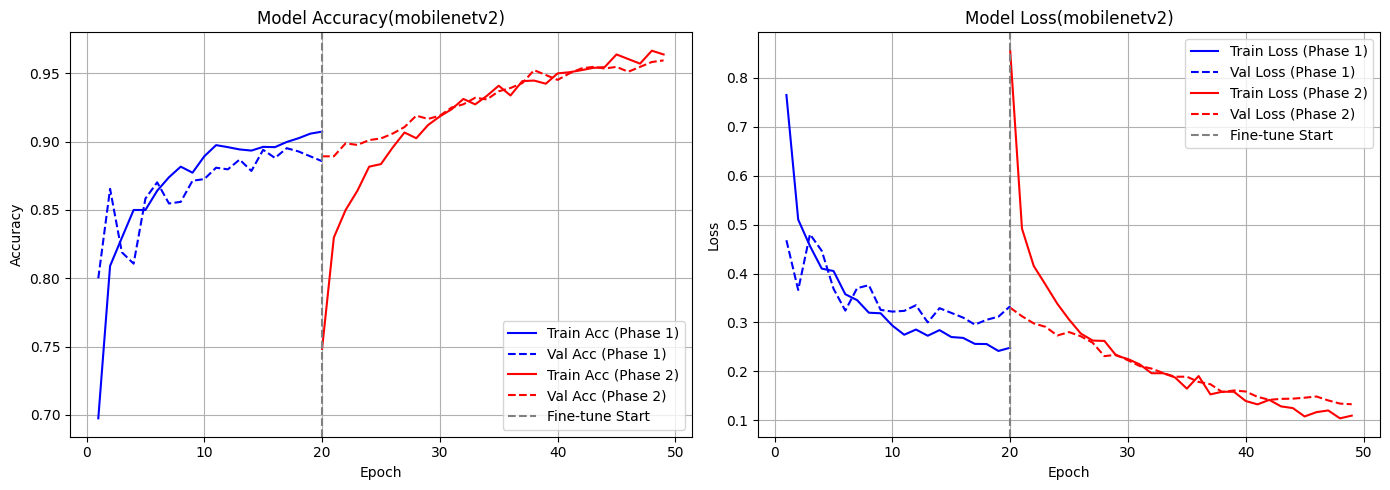

In [15]:
def plot_training_history(history_phase1, history_phase2):
    acc1 = history_phase1.history['accuracy']
    val_acc1 = history_phase1.history['val_accuracy']
    acc2 = history_phase2.history['accuracy']
    val_acc2 = history_phase2.history['val_accuracy']

    loss1 = history_phase1.history['loss']
    val_loss1 = history_phase1.history['val_loss']
    loss2 = history_phase2.history['loss']
    val_loss2 = history_phase2.history['val_loss']

    epochs_phase1 = len(acc1)
    epochs_phase2 = range(epochs_phase1, epochs_phase1 + len(acc2))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(range(1, epochs_phase1 + 1), acc1, 'b-', label='Train Acc (Phase 1)')
    axes[0].plot(range(1, epochs_phase1 + 1), val_acc1, 'b--', label='Val Acc (Phase 1)')
    axes[0].plot(epochs_phase2, acc2, 'r-', label='Train Acc (Phase 2)')
    axes[0].plot(epochs_phase2, val_acc2, 'r--', label='Val Acc (Phase 2)')
    axes[0].axvline(x=epochs_phase1, color='gray', linestyle='--', label='Fine-tune Start')
    axes[0].set_title('Model Accuracy(mobilenetv2)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(range(1, epochs_phase1 + 1), loss1, 'b-', label='Train Loss (Phase 1)')
    axes[1].plot(range(1, epochs_phase1 + 1), val_loss1, 'b--', label='Val Loss (Phase 1)')
    axes[1].plot(epochs_phase2, loss2, 'r-', label='Train Loss (Phase 2)')
    axes[1].plot(epochs_phase2, val_loss2, 'r--', label='Val Loss (Phase 2)')
    axes[1].axvline(x=epochs_phase1, color='gray', linestyle='--', label='Fine-tune Start')
    axes[1].set_title('Model Loss(mobilenetv2)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history_phase1, history_phase2)

## 9. Evaluation on Test Set

In [16]:
model.load_weights('phase2_fine_tuned.keras')

test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\n{'=' * 50}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print(f"{'=' * 50}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 810s 17s/step - accuracy: 0.9200 - loss: 0.3354

Test Accuracy: 92.00%
Test Loss: 0.3354


50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 158ms/step


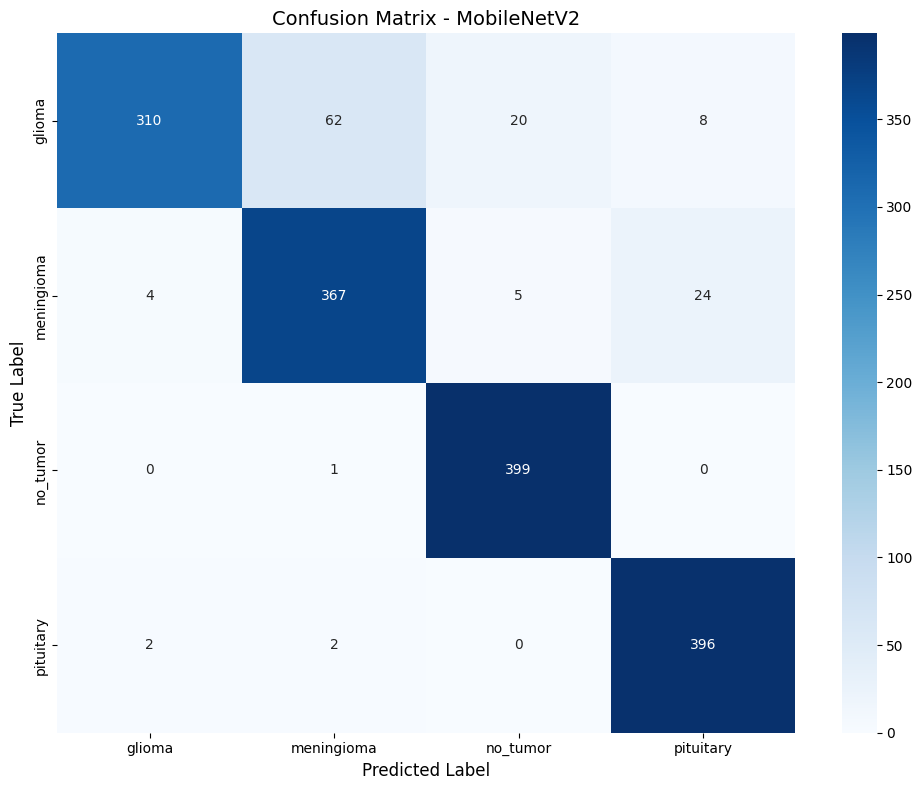


Classification Report:
              precision    recall  f1-score   support

      glioma     0.9810    0.7750    0.8659       400
  meningioma     0.8495    0.9175    0.8822       400
    no_tumor     0.9410    0.9975    0.9684       400
   pituitary     0.9252    0.9900    0.9565       400

    accuracy                         0.9200      1600
   macro avg     0.9242    0.9200    0.9183      1600
weighted avg     0.9242    0.9200    0.9183      1600



In [17]:
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - MobileNetV2', fontsize=14)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

## 10. Save Full Model

In [18]:
model.save('brain_tumor_mobilenetv2.keras')
print("Full model saved: brain_tumor_mobilenetv2.keras")

Full model saved: brain_tumor_mobilenetv2.keras


## 11. Convert to TFLite

In [19]:
def representative_data_generator():
    test_generator.reset()
    sample_count = 0
    for image_batch, _ in test_generator:
        for image in image_batch:
            yield [image[np.newaxis, ...].astype(np.float32)]
            sample_count += 1
            if sample_count >= 100:
                return


converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_generator
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]
converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32

tflite_model = converter.convert()

tflite_path = 'brain_tumor_model1.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"TFLite model saved: {tflite_path}")
print(f"Model size: {os.path.getsize(tflite_path) / (1024 * 1024):.2f} MB")

Saved artifact at '/tmp/tmpex7wcm6a'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  132196613805968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132196613807120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132196613807504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132196613806736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132196613805776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132196613807312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132196613807696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132196613808464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132196613808080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132196613805392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1321966138

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


TFLite model saved: brain_tumor_model1.tflite
Model size: 2.94 MB


## 12. Test TFLite Model

In [20]:
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input details:", input_details)
print("Output details:", output_details)

sample_images, sample_labels = next(test_generator)
sample_image = sample_images[0:1].astype(np.float32)

interpreter.set_tensor(input_details[0]['index'], sample_image)
interpreter.invoke()
tflite_pred = interpreter.get_tensor(output_details[0]['index'])

keras_pred = model.predict(sample_image, verbose=0)

print(f"\nTFLite prediction probabilities: {tflite_pred[0]}")
print(f"Keras prediction probabilities:   {keras_pred[0]}")
print(f"Predicted class: {CLASSES[np.argmax(tflite_pred)]}")
print(f"True class: {CLASSES[np.argmax(sample_labels[0])]}")

Input details: [{'name': 'serving_default_keras_tensor_154:0', 'index': 0, 'shape': array([  1, 224, 224,   3], dtype=int32), 'shape_signature': array([ -1, 224, 224,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 180, 'shape': array([1, 4], dtype=int32), 'shape_signature': array([-1,  4], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



TFLite prediction probabilities: [0.9921875  0.00390625 0.         0.00390625]
Keras prediction probabilities:   [0.3072738  0.08779415 0.00801593 0.596916  ]
Predicted class: glioma
True class: glioma


## 13. Download TFLite Model

In [21]:
from google.colab import files
files.download('brain_tumor_model1.tflite')
files.download('brain_tumor_mobilenetv2.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>